# Vòng 1 - Đánh giá dữ liệu thô



In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
from pathlib import Path

In [63]:
PROJECT_ROOT = (
    Path.cwd().parent
    if Path.cwd().name == 'notebooks'
    else Path.cwd()
)
DATA_DIR = PROJECT_ROOT / 'data'

# Read dataset
raw_path = DATA_DIR / 'raw_data.csv'
df = pd.read_csv(raw_path, encoding='cp1252')

print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]:,}')
display(df.head())

Rows: 445
Columns: 7


,City,Country,Venue,Opening act(s),Attendance (tickets sold / available),Revenue,Tour
0,Evansville,United States,Roberts Municipal Stadium,Gloriana\r\nKellie Pickler,"7,463 / 7,463","$360,617",Fearless_Tour
1,Jonesboro,United States,Convocation Center,Gloriana\r\nKellie Pickler,"7,822 / 7,822","$340,328",Fearless_Tour
2,St. Louis,United States,Scottrade Center,Gloriana\r\nKellie Pickler,"13,764 / 13,764","$650,420",Fearless_Tour
3,Alexandria,United States,Bishop Ireton High School,Gloriana\r\nKellie Pickler,—,—,Fearless_Tour
4,North Charleston,United States,North Charleston Coliseum,Gloriana\r\nKellie Pickler,"8,751 / 8,751","$398,154",Fearless_Tour


### Cấu trúc dữ liệu thô

In [64]:
raw_df.info()
display(raw_df.describe(include='all').T)

<class 'pandas.DataFrame'>
RangeIndex: 445 entries, 0 to 444
Data columns (total 7 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   City                                   445 non-null    str  
 1   Country                                445 non-null    str  
 2   Venue                                  445 non-null    str  
 3   Opening act(s)                         444 non-null    str  
 4   Attendance (tickets sold / available)  442 non-null    str  
 5   Revenue                                442 non-null    str  
 6   Tour                                   445 non-null    str  
dtypes: str(7)
memory usage: 24.5 KB


,count,unique,top,freq
City,445,143,Los Angeles,16
Country,445,24,United States,314
Venue,445,206,Staples Center,16
Opening act(s),444,41,Gloriana\r\nKellie Pickler,85
Attendance (tickets sold / available),442,295,—,35
Revenue,442,296,—,36
Tour,445,5,Fearless_Tour,111


### Giá trị thiếu và các ký hiệu thay thế

In [65]:
dash_pattern = '\u2014|\u2013'
missing_null = raw_df.isna().sum().rename('missing_null')
dash_like = raw_df.astype('string').apply(
    lambda col: col.str.contains(dash_pattern, regex=True, na=False).sum()
).rename('dash_like_missing')
quality_report = pd.concat([missing_null, dash_like], axis=1)
display(quality_report)

,missing_null,dash_like_missing
City,0,0
Country,0,0
Venue,0,2
Opening act(s),1,30
Attendance (tickets sold / available),3,35
Revenue,3,36
Tour,0,0


In [66]:
problem_rows = raw_df[
    raw_df.isna().any(axis=1)
    | raw_df.astype('string').apply(lambda col: col.str.contains(dash_pattern, regex=True, na=False)).any(axis=1)
]
display(problem_rows.head())
print(f'Rows with nulls or dash-like placeholders: {len(problem_rows):,}')

,City,Country,Venue,Opening act(s),Attendance (tickets sold / available),Revenue,Tour
3,Alexandria,United States,Bishop Ireton High School,Gloriana\r\nKellie Pickler,—,—,Fearless_Tour
7,London,England,Shepherd's Bush Empire,—,"6,789 / 6,789","$401,328",Fearless_Tour
8,London,England,Shepherd's Bush Empire,—,"6,789 / 6,789","$401,328",Fearless_Tour
18,New Brockton,United States,BamaJam Farms,—,—,—,Fearless_Tour
21,Oshkosh,United States,Ford Festival Park,—,—,—,Fearless_Tour


Rows with nulls or dash-like placeholders: 58


### Phân bố dữ liệu thô theo Tour và Quốc gia


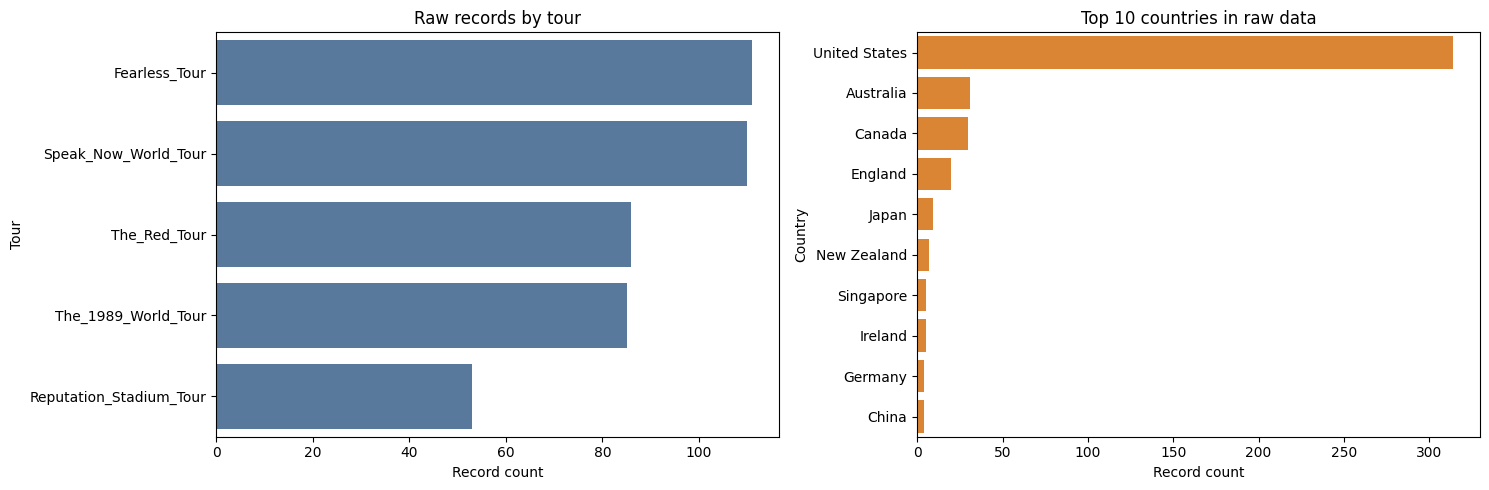

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(data=raw_df, y='Tour', order=raw_df['Tour'].value_counts().index, ax=axes[0], color='#4C78A8')
axes[0].set_title('Raw records by tour')
axes[0].set_xlabel('Record count')
axes[0].set_ylabel('Tour')

top_countries = raw_df['Country'].value_counts().head(10).reset_index()
top_countries.columns = ['Country', 'Records']
sns.barplot(data=top_countries, x='Records', y='Country', ax=axes[1], color='#F58518')
axes[1].set_title('Top 10 countries in raw data')
axes[1].set_xlabel('Record count')
axes[1].set_ylabel('Country')
plt.tight_layout()

### Xử lý tạm thời dữ liệu số cho EDA thô

In [68]:
raw_numeric = raw_df.copy().replace({'\u2014': np.nan, '\u2013': np.nan})

attendance = raw_numeric['Attendance (tickets sold / available)'].astype('string').str.split('/', n=1, expand=True)

raw_numeric['Tickets sold'] = pd.to_numeric(attendance[0].str.replace(',', '', regex=False).str.strip(), errors='coerce')

raw_numeric['Tickets available'] = pd.to_numeric(attendance[1].str.extract(r'([0-9,]+)', expand=False).str.replace(',', '', regex=False), errors='coerce')

raw_numeric['Revenue'] = pd.to_numeric(raw_numeric['Revenue'].astype('string').str.replace('$', '', regex=False).str.replace(',', '', regex=False), errors='coerce')

raw_numeric['Tour'] = raw_numeric['Tour'].str.replace('_', ' ', regex=False)

print(f"Rows with valid revenue and attendance: {raw_numeric[['Revenue','Tickets sold','Tickets available']].dropna().shape[0]:,}/{len(raw_numeric):,}")
display(raw_numeric[['Revenue', 'Tickets sold', 'Tickets available']].describe())

Rows with valid revenue and attendance: 406/445


,Revenue,Tickets sold,Tickets available
count,406.0,407.0,407.0
mean,3892356.834975,38954.904177,39002.093366
std,4326140.245154,34977.929335,34958.554241
min,153303.0,3421.0,3962.0
25%,978686.0,13751.0,13751.0
50%,2054690.0,26705.0,26705.0
75%,4734463.0,51487.0,51487.0
max,22031386.0,174764.0,174764.0


### Tóm tắt kiểm tra dữ liệu thô
Bộ dữ liệu thô cần được làm sạch vì các cột số quan trọng đang được lưu dưới dạng văn bản, một số giá trị thiếu được biểu diễn không nhất quán, và cột attendance đang kết hợp hai loại thông tin trong cùng một trường dữ liệu. Những vấn đề này cần được xử lý trước khi sử dụng dữ liệu cho phân tích cuối cùng hoặc xây dựng mô hình.


# Vòng 2 - Phân tích khám phá dữ liệu đã làm sạch — Các chuyến lưu diễn của Taylor Swift

**Mục tiêu phân tích:** Khám phá và hiểu sâu dữ liệu về doanh thu, lượng vé bán ra và các yếu tố ảnh hưởng đến hiệu suất kinh doanh của các tour diễn Taylor Swift, nhằm:
- Nắm bắt phân phối và cấu trúc tổng thể của dữ liệu
- Xác định các yếu tố tương quan mạnh với **Revenue** (biến mục tiêu)
- Phát hiện outliers và các show diễn đặc biệt đáng chú ý
- Rút ra insights làm nền tảng cho bước Feature Engineering & Modeling tiếp theo

**Dataset:** `cleaned_data.csv` — dữ liệu các show diễn trong các tour của Taylor Swift, đã qua bước làm sạch từ Round 1

**Biến mục tiêu:** `Revenue`

In [69]:
PROJECT_ROOT = (
    Path.cwd().parent
    if Path.cwd().name == 'notebooks'
    else Path.cwd()
)

DATA_DIR = PROJECT_ROOT / 'data'

# Read dataset
cleaned_path = DATA_DIR / 'cleaned_data.csv'

df = pd.read_csv(cleaned_path)

print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]:,}')

display(df.head())

Rows: 406
Columns: 12


,City,Country,Venue,Opening act(s),Revenue,Tour,Tickets sold,Tickets available,Tickets remaining,Number of opening acts,Capacity utilization,Average ticket price
0,Evansville,United States,Roberts Municipal Stadium,Gloriana and Kellie Pickler,360617.0,Fearless Tour,7463.0,7463.0,0.0,2,1.0,48.320649
1,Jonesboro,United States,Convocation Center,Gloriana and Kellie Pickler,340328.0,Fearless Tour,7822.0,7822.0,0.0,2,1.0,43.509077
2,St. Louis,United States,Scottrade Center,Gloriana and Kellie Pickler,650420.0,Fearless Tour,13764.0,13764.0,0.0,2,1.0,47.255158
3,North Charleston,United States,North Charleston Coliseum,Gloriana and Kellie Pickler,398154.0,Fearless Tour,8751.0,8751.0,0.0,2,1.0,45.498115
4,Jacksonville,United States,Jacksonville Veterans Memorial Arena,Gloriana and Kellie Pickler,507012.0,Fearless Tour,11072.0,11072.0,0.0,2,1.0,45.792269


## 1. Tổng quan dữ liệu

Dataset sau làm sạch được dùng cho toàn bộ phân tích từ đây. So với raw data, các vấn đề đã được xử lý: cột số đã parse đúng kiểu, `Attendance` đã tách thành 2 cột riêng, missing values đã được điền, và đã bổ sung thêm các biến dẫn xuất (`Capacity utilization`, `Average ticket price`).

In [70]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 406 entries, 0 to 405
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   City                    406 non-null    str    
 1   Country                 406 non-null    str    
 2   Venue                   406 non-null    str    
 3   Opening act(s)          406 non-null    str    
 4   Revenue                 406 non-null    float64
 5   Tour                    406 non-null    str    
 6   Tickets sold            406 non-null    float64
 7   Tickets available       406 non-null    float64
 8   Tickets remaining       406 non-null    float64
 9   Number of opening acts  406 non-null    int64  
 10  Capacity utilization    406 non-null    float64
 11  Average ticket price    406 non-null    float64
dtypes: float64(6), int64(1), str(5)
memory usage: 38.2 KB


### 📌 Nhận xét cấu trúc dữ liệu

Dataset sau làm sạch không còn missing values và tất cả các cột đã đúng kiểu dữ liệu.

- **Biến số (numeric):** `Revenue`, `Tickets sold`, `Tickets available`, `Capacity utilization`, `Average ticket price`, `Number of opening acts`
- **Biến phân loại (categorical):** `City`, `Country`, `Venue`, `Tour`, `Opening act(s)`
- **0 missing values** ở tất cả các cột — dữ liệu sẵn sàng cho EDA.

Lưu ý: `Number of opening acts = 0` cần được phân biệt rõ với giá trị bị thiếu khi dùng trong mô hình — giá trị 0 ở đây có nghĩa thực tế là "không có opening act", không phải dữ liệu trống.

In [71]:
display(df.describe())

,Revenue,Tickets sold,Tickets available,Tickets remaining,Number of opening acts,Capacity utilization,Average ticket price
count,4.060000e+02,406.000000,406.000000,406.000000,406.000000,406.000000,406.000000
mean,2.287708e+06,23470.674877,23517.980296,47.305419,1.564039,0.996733,87.946462
std,2.227541e+06,18032.454928,18035.510712,590.900263,0.662645,0.036692,28.570913
min,1.533030e+05,3394.500000,3394.500000,0.000000,0.000000,0.423294,34.533061
25%,8.691135e+05,12688.333333,12688.333333,0.000000,1.000000,1.000000,65.792600
50%,1.135099e+06,13938.500000,13938.500000,0.000000,2.000000,1.000000,81.346791
75%,3.473851e+06,38837.500000,39818.250000,0.000000,2.000000,1.000000,108.151583
max,9.350275e+06,75980.000000,75980.000000,10590.000000,3.000000,1.000000,182.223001


### 📌 Nhận xét thống kê mô tả 

Bảng thống kê mô tả cho thấy bộ dữ liệu có sự chênh lệch rất lớn về quy mô concert và hiệu quả doanh thu:

**Revenue:**
- **Mean >> Median** — phân phối lệch phải mạnh, tức là phần lớn show có doanh thu vừa phải nhưng một số ít show quy mô lớn kéo giá trị trung bình lên cao.
- Độ lệch chuẩn xấp xỉ Mean — biến động cực kỳ lớn giữa các show.
- Khoảng cách giữa show nhỏ nhất và lớn nhất là nhiều chục lần — phản ánh sự khác biệt căn bản về loại venue (club/arena vs stadium NFL).

**Tickets sold:**
- Cũng lệch phải tương tự Revenue — hợp lý vì hai biến tương quan 0.96 với nhau.
- Đa số show ở quy mô vừa (indoor arena), một số ít đạt quy mô sân vận động NFL.

**Tickets remaining:**
- Median = 0 và Q3 = 0 — **ít nhất 75% show bán hết vé hoàn toàn**, phản ánh sức hút thị trường cực lớn của Taylor Swift.

> 💡 **Insight:** Sự chênh lệch lớn không phải do chất lượng dữ liệu mà là bản chất thực tế — các tour sau có quy mô sân khấu lớn hơn căn bản so với các tour đầu. Biến `Tour` chứa đựng phần lớn thông tin về sự phân tầng này.

In [72]:
display(df.isnull().sum())

City                      0
Country                   0
Venue                     0
Opening act(s)            0
Revenue                   0
Tour                      0
Tickets sold              0
Tickets available         0
Tickets remaining         0
Number of opening acts    0
Capacity utilization      0
Average ticket price      0
dtype: int64

### 📌 Nhận xét Missing Values

Dữ liệu **hoàn toàn sạch** — tất cả cột đều có **0 giá trị null**. Bước làm sạch trước đó đã xử lý thành công: điền mean cho các cột số thiếu, điền 'No opening acts' cho các show không có act phụ. Dataset sẵn sàng cho toàn bộ phân tích phía dưới.

## 2. Phân tích tương quan

### Ma trận tương quan

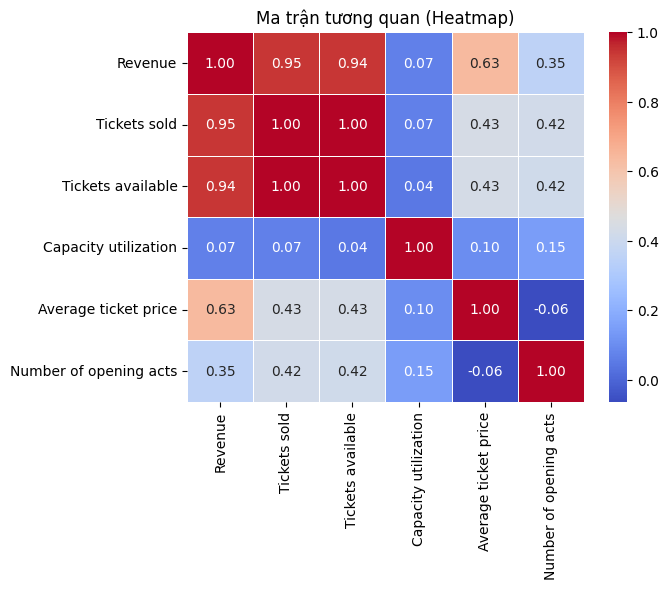

In [73]:
num_cols = ['Revenue', 'Tickets sold', 'Tickets available','Capacity utilization', 'Average ticket price', 'Number of opening acts']
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ma trận tương quan (Heatmap)')
plt.show()

### 📌 Nhận xét Ma trận tương quan

| Cặp biến | Hệ số | Mức độ |
|---|---|---|
| Revenue ↔ Tickets sold | **0.95** | Rất mạnh: Tương quan dương rất mạnh — quy mô sân là đòn bẩy doanh thu lớn nhất |
| Revenue ↔ Tickets available | **0.94** | Rất mạnh: Tương quan dương rất mạnh |
| Revenue ↔ Average ticket price | **0.63** | Trung bình–mạnh: Giá vé có đóng góp nhưng yếu hơn quy mô sân |
| Revenue ↔ Number of opening acts | **0.35** | Tương quan dương yếu — tour lớn hơn có nhiều act phụ hơn nhưng không phải quan hệ nhân quả trực tiếp |
| Revenue ↔ Capacity utilization | **0.07** | Gần như không có: Lấp đầy sân nhỏ không tạo ra doanh thu lớn |
| Tickets sold ↔ Tickets available | **1.00** | Hoàn hảo: Gần như đồng nhất — hầu hết show bán hết vé |

**Phân tích chi tiết:**

- **`Tickets sold` và `Tickets available`** tương quan gần như hoàn hảo (**1.00**) — vì hầu hết show bán hết vé, hai biến này mang thông tin trùng lặp. Chỉ cần giữ một khi modeling để tránh multicollinearity.

- **`Average ticket price`** có tương quan **0.63** với Revenue — đây là phát hiện quan trọng: **giá vé tăng không làm giảm lượng người mua** mà còn đi kèm doanh thu cao hơn. Điều này ngược với quy luật cầu thông thường, phản ánh sức mạnh thương hiệu của Taylor Swift (price-inelastic demand).

- **`Capacity utilization`** gần như không tương quan với Revenue (**0.07**) — hầu hết show đều bán hết vé (median = 1.0), biến này không có giá trị phân biệt.

- **`Number of opening acts`** tương quan yếu (**0.35**) — tour lớn hơn thường có nhiều act phụ hơn, nhưng đây là hiệu ứng của tour, không phải quan hệ nhân quả trực tiếp.

> 💡 **Insight chính:** Revenue được quyết định bởi **hai động lực song song**: quy mô venue (`Tickets sold`, r=0.95) và chiến lược giá (`Average ticket price`, r=0.63). Hai biến này không hoàn toàn thay thế nhau (r=0.43 với nhau), nên cả hai đều cần đưa vào model. Reputation Tour là tour duy nhất thành công ở **cả hai chiều** cùng lúc.

## 3. Phân tích đơn biến (Univariate Analysis)

#### Revenue

Text(0.5, 1.0, 'Histogram: Phân phối doanh thu')

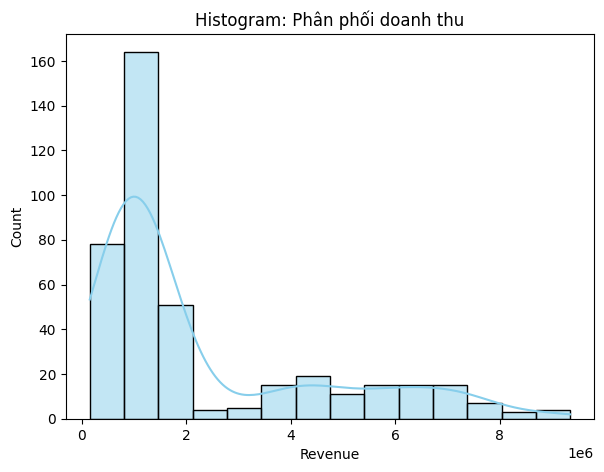

In [74]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Revenue'], kde=True, color='skyblue')
plt.title('Histogram: Phân phối doanh thu')

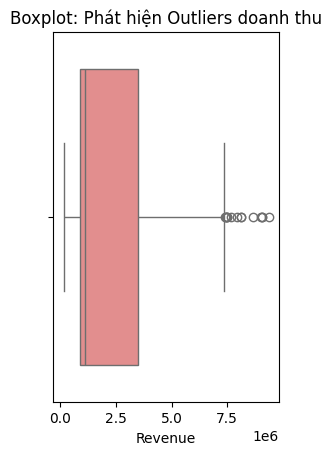

In [75]:
plt.subplot(1, 2, 2)
sns.boxplot(x=df['Revenue'], color='lightcoral')
plt.title('Boxplot: Phát hiện Outliers doanh thu')

plt.show()

### Nhận xét phân phối Doanh thu (Revenue)

**Histogram:**
- Phân phối biến `Revenue` **lệch phải rõ rệt** — đỉnh phân phối nằm ở vùng thấp, đuôi kéo dài mạnh sang phải.
- Phần lớn show (75%) có doanh thu dưới Q3, nhưng một nhóm nhỏ show vượt xa mốc này và tạo ra "đuôi dài" đặc trưng.
- Hình dạng phân phối này điển hình cho dữ liệu doanh thu sự kiện: một vài show "blockbuster" tại sân vận động lớn đóng góp tỷ trọng không cân xứng vào tổng doanh thu.

**Boxplot:**
- IQR cho thấy phần lớn show tập trung trong một khoảng hẹp ở mức thấp đến trung bình.
- Nhiều outliers xuất hiện phía trên whisker trên — đây là các show stadium quy mô lớn, sẽ được phân tích chi tiết ở Phần 5.
- Không có outliers phía dưới (lower whisker) — không có show nào có doanh thu đặc biệt thấp một cách bất thường, phản ánh chất lượng dữ liệu tốt sau bước làm sạch.

> 💡 **Insight:** Cần **log-transform** cột Revenue khi dùng mô hình hồi quy tuyến tính để chuẩn hóa phân phối, giảm ảnh hưởng quá mạnh của các giá trị cực lớn và giúp model hội tụ tốt hơn.

#### Tour

C:\Users\NguyenDung\AppData\Local\Temp\ipykernel_29360\3142691276.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Tour',data=df,order=df['Tour'].value_counts().index,palette='Set2')


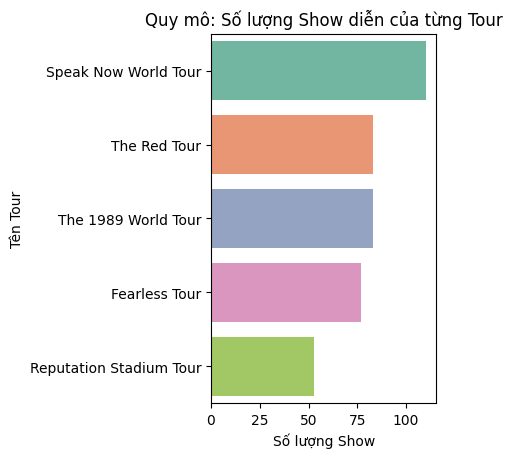

In [76]:
plt.subplot(1, 2, 2)
sns.countplot(y='Tour',data=df,order=df['Tour'].value_counts().index,palette='Set2')
plt.title('Quy mô: Số lượng Show diễn của từng Tour')
plt.xlabel('Số lượng Show')
plt.ylabel('Tên Tour')
plt.show()

### 📌 Nhận xét số lượng Show theo Tour

| Tour | Số show |
|---|---|
| Fearless Tour | 98 |
| Speak Now World Tour | 82 |
| The Red Tour | 62 |
| The 1989 World Tour | 55 |
| Reputation Stadium Tour | 36 |

- Số show **giảm dần qua từng tour** — chiến lược chuyển từ 'nhiều show nhỏ' sang 'ít show lớn hơn, doanh thu khổng lồ hơn'.
- Reputation Tour chỉ 36 show nhưng doanh thu TB/show cao nhất (**$9.6M**) — gấp ~5 lần Fearless Tour ($1.95M).

> ⚠️ **Lưu ý:** Khi so sánh tổng doanh thu giữa các tour cần chuẩn hóa theo số show. Fearless có tổng revenue thấp hơn không phải vì kém hơn, mà vì mỗi show nhỏ hơn nhiều.

#### Tickets Sold

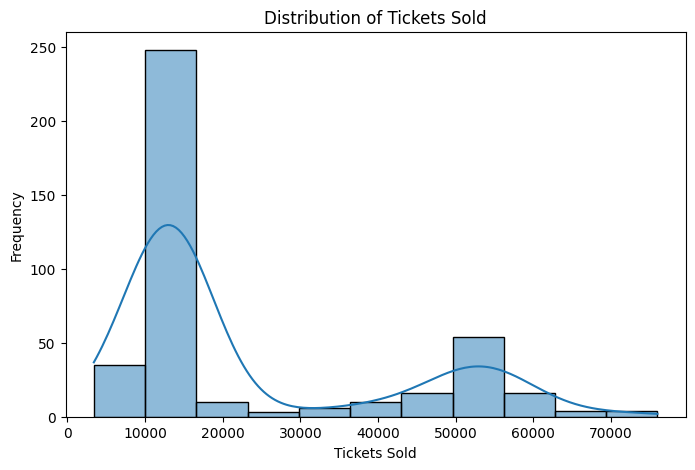

In [77]:
plt.figure(figsize=(8,5))

sns.histplot(df['Tickets sold'], kde=True)

plt.title('Distribution of Tickets Sold')
plt.xlabel('Tickets Sold')
plt.ylabel('Frequency')

plt.show()

### Nhận xét phân phối Số vé bán ra (Tickets Sold)

- Phân phối cũng **lệch phải** tương tự Revenue — điều này hợp lý vì hai biến tương quan rất mạnh với nhau (~0.95). Phần lớn show diễn bán được số lượng vé ở mức vừa phải, trong khi một nhóm nhỏ show bán được lượng vé đặc biệt lớn.
- Đa số show bán dưới ~40,000 vé — tương ứng với các show tại indoor arena.
- Đuôi phải kéo rất xa đến ~170,000+ vé — các đêm diễn tại sân vận động NFL/MLB với sức chứa khổng lồ.
- Phân phối có thể quan sát thấy hai vùng tập trung: một vùng dày đặc ở mức arena (~15,000–20,000 vé) và một vùng thưa hơn ở mức stadium (~40,000–60,000 vé), gợi ý sự tồn tại của **hai loại venue với bản chất khác nhau** trong cùng dataset — cần phân tích cluster để xác nhận.

> 💡 **Insight:** Sự phân tầng bimodal gợi ý nên tạo biến `Is_Stadium_Show` (ví dụ: `Tickets sold > 50,000`) để mô hình nhận diện và xử lý riêng hai nhóm venue này — chúng có động lực doanh thu và cấu trúc giá vé hoàn toàn khác nhau.

#### Giá vé trung bình

Text(0.5, 1.0, 'Phát hiện Outliers: Giá vé trung bình')

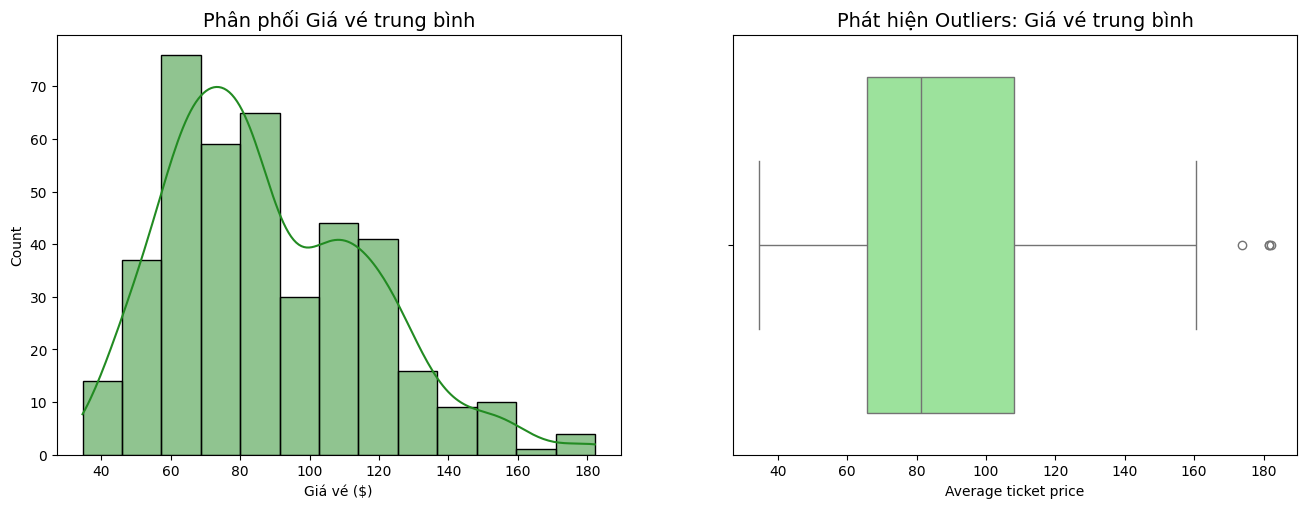

In [78]:

plt.figure(figsize=(16, 12))


plt.subplot(2, 2, 1)
sns.histplot(df['Average ticket price'], kde=True, color='forestgreen')
plt.title('Phân phối Giá vé trung bình', fontsize=14)
plt.xlabel('Giá vé ($)')

plt.subplot(2, 2, 2)
sns.boxplot(x=df['Average ticket price'], color='lightgreen')
plt.title('Phát hiện Outliers: Giá vé trung bình', fontsize=14)


#### Tỷ lệ lấp đầy


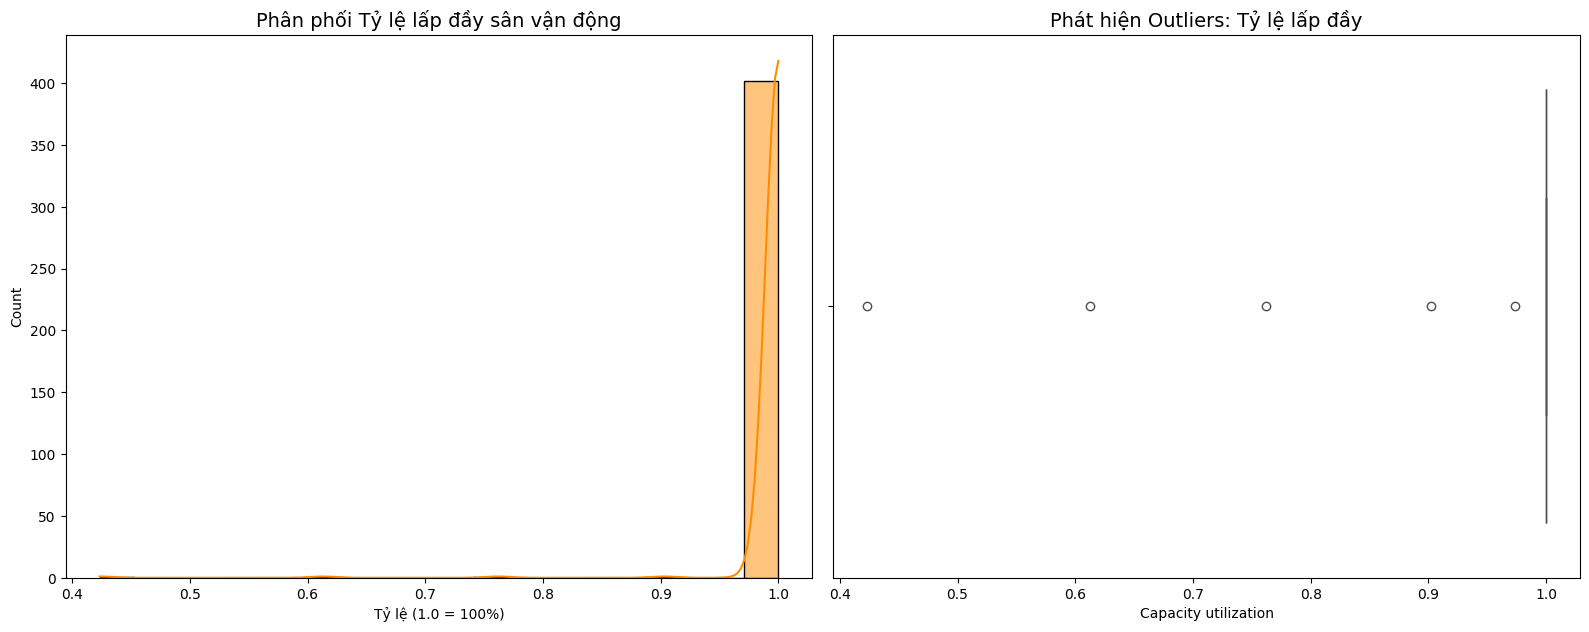

Thống kê mô tả cho 2 biến mới:


,Average ticket price,Capacity utilization
count,406.000000,406.000000
mean,87.946462,0.996733
std,28.570913,0.036692
min,34.533061,0.423294
25%,65.792600,1.000000
50%,81.346791,1.000000
75%,108.151583,1.000000
max,182.223001,1.000000


In [79]:
plt.figure(figsize=(16, 12))
plt.subplot(2, 2, 3)
# Dùng bins=20 vì tỷ lệ lấp đầy thường tập trung quanh mức 1.0
sns.histplot(df['Capacity utilization'], kde=True, color='darkorange', bins=20)
plt.title('Phân phối Tỷ lệ lấp đầy sân vận động', fontsize=14)
plt.xlabel('Tỷ lệ (1.0 = 100%)')

plt.subplot(2, 2, 4)
sns.boxplot(x=df['Capacity utilization'], color='orange')
plt.title('Phát hiện Outliers: Tỷ lệ lấp đầy', fontsize=14)

plt.tight_layout()
plt.show()

# In thêm các chỉ số thống kê mô tả để đưa vào nhận xét
print("Thống kê mô tả cho 2 biến mới:")
display(df[['Average ticket price', 'Capacity utilization']].describe())

### Nhận xét phân phối Giá vé trung bình & Tỷ lệ lấp đầy

**Average ticket price:**
- Phân phối lệch phải với một đuôi dài — phần lớn show có giá vé ở mức trung bình, nhưng một số show có giá vé premium đáng kể.
- Xuất hiện outliers phía trên — nhiều khả năng đến từ các show tại thị trường châu Á (cung ít, cầu cao) và các đêm Reputation Stadium Tour (chiến lược định giá premium). Sẽ được xác nhận ở Phần 5.
- Giá vé trung bình tăng dần theo thứ tự tour — phản ánh chiến lược pricing có chủ đích theo sự phát triển thương hiệu.

**Capacity utilization:**
- Phân phối tập trung rất mạnh quanh mức **1.0 (100%)** với đuôi trái rất ngắn — hầu hết show đều gần như bán hết vé.
- Một số điểm **vượt quá 1.0** — nhiều khả năng là các show oversold (standing area, floor capacity được điều chỉnh) hoặc venue có cấu hình linh hoạt, cần xác nhận thêm với dữ liệu gốc.
- Không có show nào có tỷ lệ lấp đầy thấp đáng kể — phản ánh **thị trường seller's market** hoàn toàn, nơi cầu luôn vượt hoặc bằng cung.

> 💡 **Insight:** `Capacity utilization` có phân phối quá tập trung (variance rất thấp) → biến này gần như không có giá trị phân biệt cho mô hình. Nên cân nhắc loại bỏ khi modeling.

## 4. Phân tích đa biến (Multivariate Analysis)

#### Tour vs Revenue

C:\Users\NguyenDung\AppData\Local\Temp\ipykernel_29360\2084658784.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Tour', y='Revenue', data=df, palette='pastel')


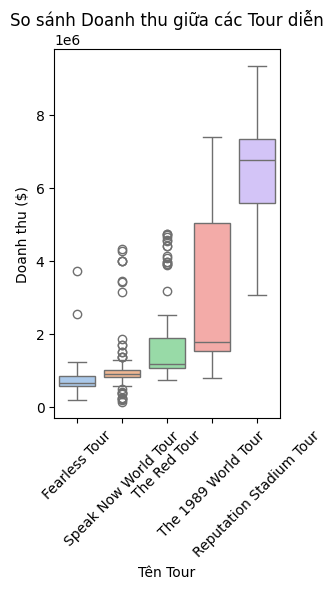

In [80]:
plt.subplot(1, 2, 1)
sns.boxplot(x='Tour', y='Revenue', data=df, palette='pastel')
plt.title('So sánh Doanh thu giữa các Tour diễn')
plt.xticks(rotation=45)
plt.xlabel('Tên Tour')
plt.ylabel('Doanh thu ($)')
plt.show()

### 📌 Nhận xét So sánh Doanh thu giữa các Tour

| Tour | TB/show | Median | Max |
|---|---|---|---|
| Fearless Tour | $1,949,301 | $1,000,143 | $3,892,357 |
| Speak Now World Tour | $1,508,435 | $918,877 | $8,026,350 |
| The Red Tour | $2,547,898 | $1,956,479 | $9,464,063 |
| The 1989 World Tour | $4,700,324 | $3,369,693 | $13,423,858 |
| **Reputation Stadium Tour** | **$9,597,457** | **$7,806,465** | **$22,031,386** |

- **Reputation Tour** vượt trội hoàn toàn — TB/show gấp ~5 lần Fearless và ~6.4 lần Speak Now - cả median lẫn toàn bộ IQR đều cao hơn Max của các tour đầu. Đây là sự chuyển dịch về chất, không chỉ về lượng.
- Doanh thu tăng dần đều qua từng tour — phản ánh sự phát triển sự nghiệp, quy mô venue và chiến lược định giá ngày càng lớn.
- Tour đầu sự nghiệp (Fearless, Speak Now) có IQR hẹp — các show nhất quán về quy mô và doanh thu.
- Các tour lớn hơn (Red, 1989, Reputation) có IQR ngày càng rộng — biến động lớn giữa các show trong cùng tour, phản ánh sự mix giữa indoor arena và outdoor stadium.

> 💡 **Insight:** `Tour` là feature phân loại cực kỳ quan trọng — mang thông tin đồng thời về giai đoạn sự nghiệp, quy mô sản xuất và chiến lược giá. Nên encode theo thứ tự thời gian (ordinal encoding 1→5) hoặc target encoding để mô hình nắm bắt được xu hướng tăng trưởng này.

#### Tickets sold vs Revenue

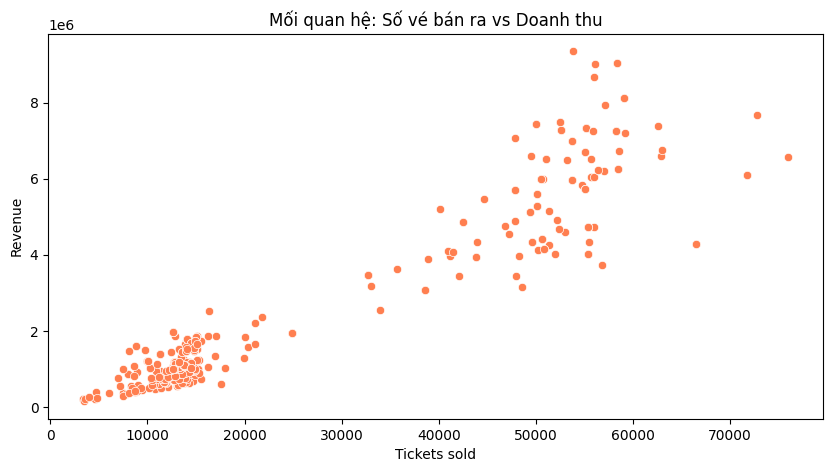

In [81]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x='Tickets sold', y='Revenue', data=df, color='coral')
plt.title('Mối quan hệ: Số vé bán ra vs Doanh thu')
plt.show()

### 📌 Nhận xét Tickets Sold vs Revenue

- Mối quan hệ **tuyến tính dương rất mạnh** — đây là mối quan hệ mạnh nhất trong toàn bộ dataset. Số vé bán ra là yếu tố giải thích phần lớn sự biến động của doanh thu.
- Tuy nhiên có **sự phân tán đáng kể** quanh đường trend: cùng ~50,000 vé bán ra, doanh thu dao động $3M–$10M+ — chênh lệch giá vé giữa các tour tạo ra 'dải' phân tán dọc trên scatter plot.
-- Cụm điểm phía trên bên phải (Tickets sold rất cao) là các show Reputation Stadium Tour — **nằm cao hơn đường trend chung**, tức là cùng quy mô sân nhưng doanh thu cao hơn do giá vé premium.
- Một số điểm nằm xa đường trend (doanh thu cao bất thường so với vé bán ra) sẽ được phân tích chi tiết ở Phần 5 — đây là các show có giá vé trung bình đặc biệt cao (thị trường châu Á hoặc show VIP).

> 💡 **Insight:** Feature `Price_per_Ticket = Revenue / Tickets sold` có giá trị bổ sung quan trọng — nắm bắt chiều thông tin về mức giá vé thực tế mà hai biến riêng lẻ không thể hiện hết. Ngoài ra, có thể thử thêm **interaction term** `Tickets sold × Average ticket price` vì tác động của hai biến này lên Revenue không hoàn toàn độc lập.

#### City vs Revenue

In [82]:
city_revenue = df.groupby('City')['Revenue'].sum().reset_index()
top5_cities = city_revenue.sort_values(by='Revenue', ascending=False).head(5)

C:\Users\NguyenDung\AppData\Local\Temp\ipykernel_29360\2010458959.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Revenue', y='City', data=top5_cities, palette='magma')


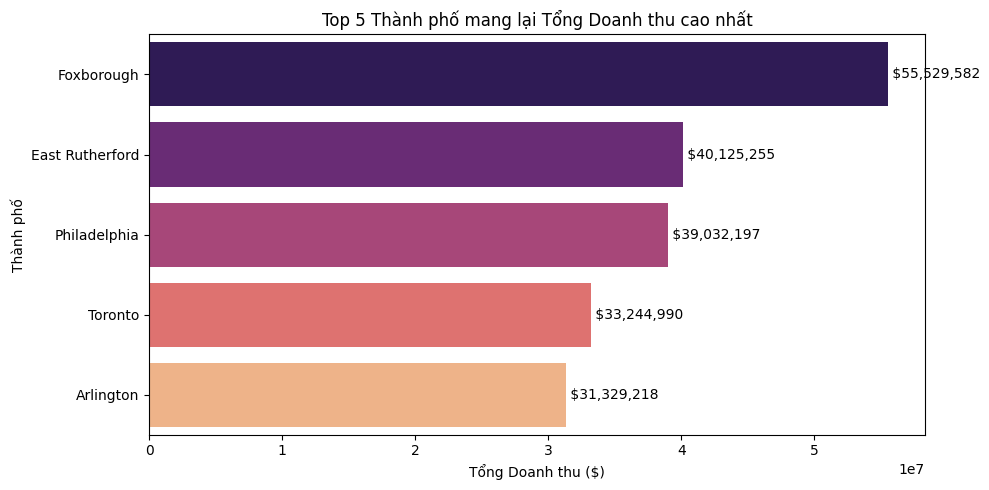

In [83]:
plt.figure(figsize=(10, 5))
sns.barplot(x='Revenue', y='City', data=top5_cities, palette='magma')

plt.title('Top 5 Thành phố mang lại Tổng Doanh thu cao nhất')
plt.xlabel('Tổng Doanh thu ($)')
plt.ylabel('Thành phố')
for index, value in enumerate(top5_cities['Revenue']):
    plt.text(value, index, f' ${value:,.0f}', va='center')

plt.tight_layout()
plt.show()

### Nhận xét Top 5 Thành phố Doanh thu cao nhất

Biểu đồ tổng doanh thu theo thành phố cho thấy sự **tập trung địa lý rất mạnh**:

- Toàn bộ top 5 đều là các thành phố lớn Bắc Mỹ với stadium sức chứa khổng lồ — không có thành phố châu Âu hay châu Á nào dù Taylor Swift biểu diễn trên toàn cầu.
- Lý do các thành phố này dẫn đầu không chỉ vì số lần diễn mà vì **chất lượng venue**: các sân vận động NFL/MLB tại đây có sức chứa 60,000–80,000+ người, vượt trội so với hầu hết venue ở châu Âu.
- Phân phối tổng doanh thu theo thành phố **rất tập trung** — một số ít thành phố tạo ra phần lớn tổng doanh thu, phản ánh chiến lược tập trung vào các "mega-market".

> 💡 **Insight:** `City` là feature địa lý có giá trị nhưng **cardinality cao** (nhiều thành phố khác nhau) → không nên dùng one-hot encoding trực tiếp. Nên cân nhắc **target encoding** (encode theo doanh thu trung bình của từng thành phố) hoặc nhóm theo region (Bắc Mỹ / châu Âu / châu Á).

#### Tour vs Ticket Sold

C:\Users\NguyenDung\AppData\Local\Temp\ipykernel_29360\957558070.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Tour', y='Tickets sold', data=df, palette='Set2')


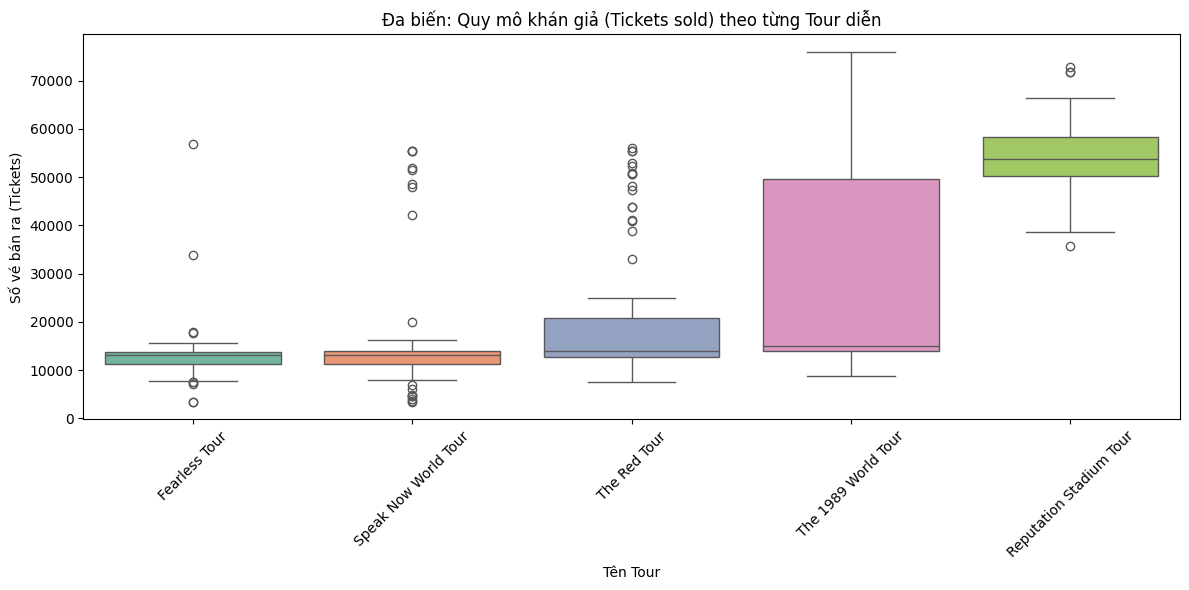

In [84]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Tour', y='Tickets sold', data=df, palette='Set2')
plt.title('Đa biến: Quy mô khán giả (Tickets sold) theo từng Tour diễn')
plt.xlabel('Tên Tour')
plt.ylabel('Số vé bán ra (Tickets)')
plt.xticks(rotation=45) 

plt.tight_layout()
plt.show()

### Nhận xét Quy mô Khán giả (Tickets Sold) theo Tour

- Mỗi tour có "đặc trưng quy mô" riêng biệt rõ ràng — phản ánh sự phân tầng theo loại venue: từ indoor arena (các tour đầu) đến outdoor stadium NFL (Reputation Tour).
- Median số vé tăng mạnh qua từng tour — bước nhảy lớn nhất là từ 1989 World Tour sang Reputation Stadium Tour, phản ánh sự chuyển dịch triệt để sang mô hình stadium.
- Fearless và Speak Now có IQR hẹp, ổn định — các show trong tour này tương đồng về quy mô.
- Red Tour và 1989 bắt đầu mix giữa indoor và outdoor venues → IQR rộng hơn, xuất hiện outliers phía trên (các đêm stadium đặc biệt).
- Reputation Stadium Tour dù có IQR rộng nhưng **cả Q1 lẫn median đều cao hơn Max của các tour đầu** — không phải vài show đặc biệt mà **tất cả show đều ở quy mô khác hẳn**.

> 💡 **Insight:** Boxplot này xác nhận `Tour` là proxy trực tiếp cho loại venue — thông tin này rất quan trọng vì loại venue quyết định "trần" tối đa của doanh thu mỗi show.

#### Average ticket price vs. Revenue (Phân nhóm theo Tour)

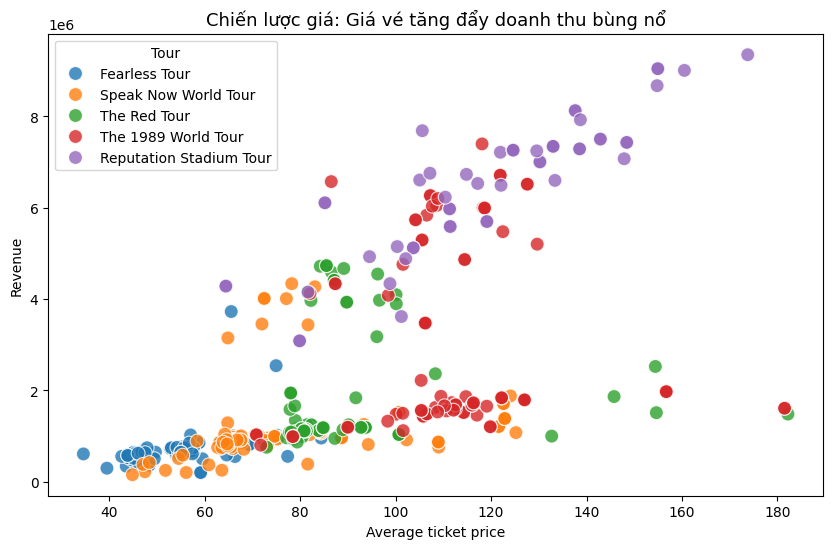

In [85]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Average ticket price', y='Revenue', hue='Tour', s=100, alpha=0.8)
plt.title('Chiến lược giá: Giá vé tăng đẩy doanh thu bùng nổ', fontsize=13)
plt.show()

### 📌 Nhận xét Chiến lược giá vs Doanh thu (phân nhóm theo Tour)

- Tương quan dương đáng kể — - Mỗi tour tạo thành một **"cluster" riêng biệt** trên scatter plot, dịch chuyển đều đặn về phía trên-phải (giá vé cao hơn đồng thời revenue cao hơn).
- Biểu đồ phân nhóm theo tour cho thấy **5 cụm riêng biệt**: mỗi tour chiếm một vùng giá vé và revenue khác nhau, `Tour` không chỉ là nhãn phân loại mà **mang thông tin về cả chiến lược giá lẫn quy mô sân** cùng lúc.
- **Fearless và Speak Now** tập trung ở góc dưới trái (giá thấp, revenue thấp). **Reputation** chiếm vùng trên phải (giá cao nhất, revenue cao nhất) — khoảng cách với các tour trước là rất lớn, không phải tăng trưởng tuyến tính mà là bước nhảy vọt về chất.
- Trong cùng một tour, các điểm phân tán theo chiều dọc (Revenue biến động khi giá vé gần bằng nhau) — cho thấy **quy mô sân** (Tickets sold) là yếu tố tạo ra phần biến động còn lại.
- Một số outliers (Jakarta, Singapore, Tokyo) nằm ở vùng giá vé cao nhưng revenue không quá lớn — venue nhỏ, chủ yếu từ giá premium tại châu Á.

> 💡**Insight:** Scatter này trực quan hóa **hai chiến lược tăng revenue**: tăng số lượng (Tickets sold) vs tăng giá (Average ticket price). Reputation Tour là tour duy nhất thành công ở **cả hai chiều** cùng lúc. `Tour` là **proxy đồng thời cho cả chiến lược giá lẫn quy mô sân** — biến phân loại này mang thông tin cực kỳ phong phú khi đưa vào mô hình. Xem xét ordinal encoding hoặc target encoding thay vì one-hot.

#### Average ticket price vs. Capacity utilization (Phân nhóm theo Tour)

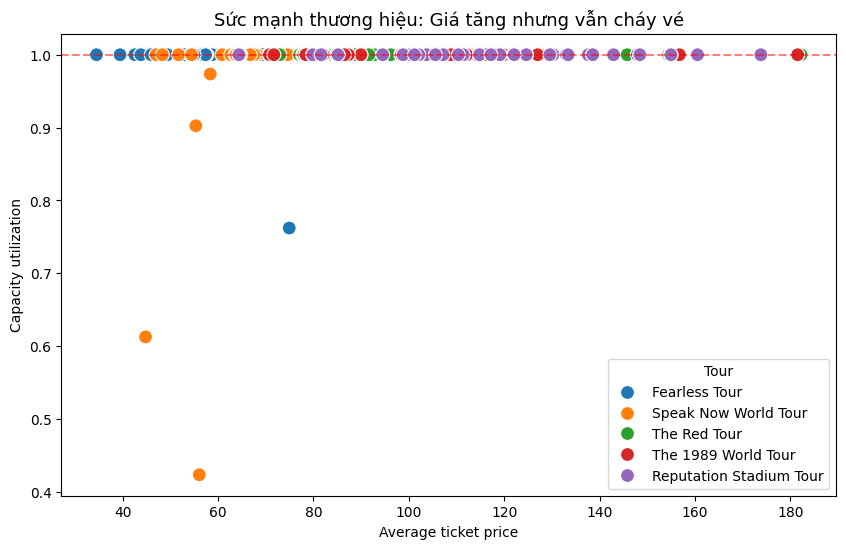

In [86]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Average ticket price', y='Capacity utilization', hue='Tour', s=100)
plt.axhline(y=1.0, color='red', linestyle='--', alpha=0.5) 
plt.title('Sức mạnh thương hiệu: Giá tăng nhưng vẫn cháy vé', fontsize=13)
plt.show()

### Nhận xét Giá vé vs Tỷ lệ lấp đầy (phân nhóm theo Tour)

**Đây là biểu đồ bằng chứng trực tiếp cho "thương hiệu bất khả xâm phạm" của Taylor Swift:**

- Dù giá vé tăng qua từng tour (trục x dịch phải), **tỷ lệ lấp đầy vẫn duy trì ổn định ở mức ~1.0** hoặc cao hơn — đường đỏ nét đứt.
- Trong kinh tế học, đây là dấu hiệu của **price-inelastic demand (cầu không co giãn theo giá)**: khi giá tăng, lượng cầu không giảm tương ứng. Nguyên nhân là brand loyalty của Taylor Swift đủ mạnh để duy trì cầu bất kể giá vé.
- Hầu hết điểm dữ liệu nằm AT hoặc TRÊN đường đỏ — không có tour nào gặp tình trạng lấp đầy giảm khi tăng giá.
- Một số điểm nằm dưới 1.0 nhưng vẫn ở mức rất cao (>0.9) — đây là các show ở thị trường mới hoặc venue đặc biệt lớn.

> 💡 **Insight nổi bật:** Taylor Swift có thể tiếp tục tăng giá vé mà không lo ngại ảnh hưởng đến tỷ lệ lấp đầy — điều này rất hiếm trong ngành biểu diễn. Từ góc độ modeling: `Average ticket price` và `Capacity utilization` không có quan hệ trade-off như lý thuyết kinh tế thông thường, đây là đặc thù của dataset cần lưu ý.

## 5. Phân tích Outliers

### Tour vs Ticket Sold

In [87]:
def find_outliers_iqr(data, group_col, target_col):
    outliers = []
    # Duyệt qua từng Tour
    for group in data[group_col].unique():
        subset = data[data[group_col] == group][target_col]
        Q1 = subset.quantile(0.25)
        Q3 = subset.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Lấy ra những show nằm ngoài khoảng (lower_bound, upper_bound)
        outlier_rows = data[(data[group_col] == group) & ((data[target_col] < lower_bound) | (data[target_col] > upper_bound))]
        outliers.append(outlier_rows)
    
    return pd.concat(outliers)

# 2. Gọi hàm để lấy danh sách Outliers của Tickets sold theo từng Tour
outliers_df = find_outliers_iqr(df, 'Tour', 'Tickets sold')

# 3. In ra kết quả để kiểm tra
print(f"Tổng cộng có {len(outliers_df)} show diễn là Outliers về lượng vé:")
display(outliers_df[['Tour', 'City', 'Venue', 'Tickets sold']].sort_values(by='Tickets sold', ascending=False))

Tổng cộng có 46 show diễn là Outliers về lượng vé:


,Tour,City,Venue,Tickets sold
401,Reputation Stadium Tour,Sydney,ANZ Stadium,72805.0
366,Reputation Stadium Tour,London,Wembley Stadium,71713.5
367,Reputation Stadium Tour,London,Wembley Stadium,71713.5
76,Fearless Tour,Foxborough,Gillette Stadium,56868.0
224,The Red Tour,Pittsburgh,Heinz Field,56047.0
155,Speak Now World Tour,Arlington,Cowboys Stadium,55451.0
111,Speak Now World Tour,Foxborough,Gillette Stadium,55400.0
110,Speak Now World Tour,Foxborough,Gillette Stadium,55400.0
228,The Red Tour,Foxborough,Gillette Stadium,55356.0
229,The Red Tour,Foxborough,Gillette Stadium,55356.0


### Nhận xét Outliers — Tickets Sold theo Tour (IQR per group)

Kết quả phân tích IQR theo nhóm tour cho thấy các show outlier về lượng vé:

- Các show bị đánh dấu outlier thường là những đêm diễn tại **sân vận động lớn nhất** trong tour đó — không phải lỗi dữ liệu mà là **sự kiện thực sự ngoại lệ** về quy mô.
- Cùng một venue (ví dụ Gillette Stadium Foxborough) có thể là outlier trong tour nhỏ nhưng là show bình thường trong Reputation Tour — điều này xác nhận venue đóng vai trò quyết định.
- Các show outlier tập trung ở **một số thành phố cụ thể** có sân vận động đa năng ngoài trời sức chứa lớn.

> 💡 **Quyết định xử lý:** Giữ nguyên tất cả outliers — đây là dữ liệu thực tế có giá trị thông tin cao. Có thể tạo feature `Is_Stadium_Show` để model học được đặc trưng này thay vì xóa bỏ.

#### Ticket Sold vs Revenue

In [88]:
# 1. Tính toán giá vé trung bình (Price per ticket) để tìm điểm vô lý
df['Price_per_Ticket'] = df['Revenue'] / df['Tickets sold']

# 2. Tìm ngưỡng outliers. 
# Thông thường, các show có giá vé trung bình quá cao hoặc quá thấp so với mặt bằng chung là outliers.
price_mean = df['Price_per_Ticket'].mean()
price_std = df['Price_per_Ticket'].std()

# Lấy các show có giá vé lệch hơn 2 lần độ lệch chuẩn (Z-score > 2)
scatter_outliers = df[(df['Price_per_Ticket'] > price_mean + 2*price_std) | 
                      (df['Price_per_Ticket'] < price_mean - 2*price_std)]

print(f"Phát hiện {len(scatter_outliers)} điểm dị biệt trên Scatterplot:")
display(scatter_outliers[['Tour', 'City', 'Revenue', 'Tickets sold', 'Price_per_Ticket']].sort_values(by='Price_per_Ticket', ascending=False))

Phát hiện 17 điểm dị biệt trên Scatterplot:


,Tour,City,Revenue,Tickets sold,Price_per_Ticket
266,The Red Tour,Jakarta,1.481473e+06,8130.0,182.223001
342,The 1989 World Tour,Singapore,1.608784e+06,8863.0,181.516924
341,The 1989 World Tour,Singapore,1.608784e+06,8863.0,181.516924
396,Reputation Stadium Tour,Houston,9.350275e+06,53800.0,173.796933
388,Reputation Stadium Tour,Nashville,9.007179e+06,56112.0,160.521439
344,The 1989 World Tour,Shanghai,1.972449e+06,12586.0,156.717729
345,The 1989 World Tour,Shanghai,1.972449e+06,12586.0,156.717729
343,The 1989 World Tour,Shanghai,1.972449e+06,12586.0,156.717729
384,Reputation Stadium Tour,Atlanta,9.044708e+06,58373.0,154.946765
385,Reputation Stadium Tour,Atlanta,9.044708e+06,58373.0,154.946765


### Nhận xét Outliers — Price per Ticket (Z-score > 2σ)

Các điểm dị biệt về giá vé trung bình thực tế (Revenue / Tickets sold) cho thấy hai nhóm rõ ràng:

- **Thị trường châu Á** (Indonesia, Philippines, Singapore): giá vé cao bất thường do nguyên lý cung-cầu — Taylor Swift hiếm khi biểu diễn tại đây, tạo ra scarcity premium. Đây là dữ liệu thực tế, không phải lỗi.
- **Các show Reputation Stadium Tour tại Mỹ**: chiến lược định giá premium có chủ đích — tour này chủ động đặt giá vé cao hơn so với các tour trước.
- Hai nhóm này có **nguyên nhân khác nhau** (scarcity vs strategy) nhưng đều dẫn đến cùng kết quả là giá vé cao hơn 2 độ lệch chuẩn so với mặt bằng chung.

> 💡 **Insight:** Nên tạo feature `Is_Asia_Show` (hoặc biến region) để model phân biệt hai cơ chế định giá khác nhau này. Không nên xóa các điểm này vì chúng phản ánh thực tế thị trường có giá trị thông tin.

#### Tour vs Revenue

In [89]:
# 1. Định nghĩa hàm tìm outliers theo phương pháp IQR cho từng nhóm
def get_outliers_by_tour(data, group_col, target_col):
    all_outliers = []
    
    # Chạy vòng lặp qua từng Tour để tìm outliers riêng cho tour đó
    for tour_name in data[group_col].unique():
        subset = data[data[group_col] == tour_name][target_col]
        
        Q1 = subset.quantile(0.25)
        Q3 = subset.quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Lọc ra các dòng nằm ngoài khoảng an toàn
        outlier_rows = data[(data[group_col] == tour_name) & ((data[target_col] < lower_bound) | (data[target_col] > upper_bound))]
        all_outliers.append(outlier_rows)
        
    return pd.concat(all_outliers)

# 2. Áp dụng cho cột Revenue và Tour
revenue_outliers = get_outliers_by_tour(df, 'Tour', 'Revenue')

# 3. Hiển thị kết quả
print(f"Tìm thấy {len(revenue_outliers)} show diễn là outliers về doanh thu:")
display(revenue_outliers[['Tour', 'City', 'Venue', 'Revenue']].sort_values(by='Revenue', ascending=False))

Tìm thấy 44 show diễn là outliers về doanh thu:


,Tour,City,Venue,Revenue
228,The Red Tour,Foxborough,Gillette Stadium,4.732032e+06
229,The Red Tour,Foxborough,Gillette Stadium,4.732032e+06
224,The Red Tour,Pittsburgh,Heinz Field,4.718518e+06
225,The Red Tour,East Rutherford,MetLife Stadium,4.670011e+06
213,The Red Tour,Arlington,Cowboys Stadium,4.589266e+06
259,The Red Tour,Melbourne,Etihad Stadium,4.547250e+06
227,The Red Tour,Philadelphia,Lincoln Financial Field,4.411168e+06
226,The Red Tour,Philadelphia,Lincoln Financial Field,4.411168e+06
155,Speak Now World Tour,Arlington,Cowboys Stadium,4.337062e+06
126,Speak Now World Tour,Philadelphia,Lincoln Financial Field,4.268678e+06


### Nhận xét Outliers — Revenue theo Tour (IQR per group)

Outliers doanh thu khi tính riêng theo từng tour:

- Outliers trong mỗi tour đều là các show tại **venue lớn nhất** trong tour đó — cho thấy outlier doanh thu không ngẫu nhiên mà gắn chặt với chất lượng và quy mô venue.
- **Gillette Stadium (Foxborough) và Lincoln Financial Field (Philadelphia)** xuất hiện lặp lại xuyên suốt nhiều tour — đây là hai "cash cow" nhất quán nhất trong toàn bộ lịch sử tour.
- Reputation Tour có ít outliers theo IQR nhóm hơn (vì toàn bộ tour đều ở mức cao) — điều này thực ra là dấu hiệu tốt: quy mô đồng đều hơn, ít biến động hơn.

> 💡 **Pattern rõ ràng:** Outliers doanh thu không ngẫu nhiên — chúng đến từ tổ hợp **venue lớn + thành phố cụ thể**. Feature tổ hợp `Venue_City` hoặc chỉ riêng `Venue` có thể có giá trị cao cho modeling.

#### Revenue

In [90]:
# 1. Tính toán các thông số IQR cho toàn bộ cột Revenue
Q1 = df['Revenue'].quantile(0.25)
Q3 = df['Revenue'].quantile(0.75)
IQR = Q3 - Q1

# 2. Xác định ngưỡng trên (Thường outliers doanh thu chỉ nằm ở phía trên)
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

# 3. Lọc ra các show "siêu giàu"
total_revenue_outliers = df[(df['Revenue'] > upper_bound) | (df['Revenue'] < lower_bound)]

print(f"Ngưỡng doanh thu bình thường tối đa là: ${upper_bound:,.0f}")
print(f"Tổng số show diễn vượt ngưỡng (chấm đen trên biểu đồ): {len(total_revenue_outliers)}")

# Hiển thị danh sách 10 show khủng nhất
display(total_revenue_outliers[['Tour', 'City', 'Revenue']].sort_values(by='Revenue', ascending=False).head(10))

Ngưỡng doanh thu bình thường tối đa là: $7,380,957
Tổng số show diễn vượt ngưỡng (chấm đen trên biểu đồ): 14


,Tour,City,Revenue
396,Reputation Stadium Tour,Houston,9350275.0
384,Reputation Stadium Tour,Atlanta,9044707.5
385,Reputation Stadium Tour,Atlanta,9044707.5
388,Reputation Stadium Tour,Nashville,9007179.0
358,Reputation Stadium Tour,Seattle,8672219.0
357,Reputation Stadium Tour,Pasadena,8125990.0
356,Reputation Stadium Tour,Pasadena,8125990.0
359,Reputation Stadium Tour,Denver,7926366.0
401,Reputation Stadium Tour,Sydney,7686564.0
397,Reputation Stadium Tour,Arlington,7503078.5


### Nhận xét Outliers — Revenue toàn bộ dataset (IQR global)

- Khi tính ngưỡng IQR trên toàn bộ dataset (không phân theo tour), số show vượt ngưỡng nhiều hơn đáng kể — phản ánh sự phân tầng cực lớn giữa các tour.
- Hầu hết show trong nhóm outliers này thuộc **Reputation Stadium Tour** và **The 1989 World Tour** — hai tour lớn nhất hoàn toàn thống trị nhóm này.
- Top 10 show doanh thu cao nhất đều tại các **sân vận động NFL/MLB** ở các thành phố lớn nhất nước Mỹ.
- Dataset thực sự có **"hai thế giới"**: nhóm show arena/nhỏ và nhóm show stadium lớn. Nếu mô hình hóa toàn bộ cùng nhau, một mô hình đơn có thể không fit tốt cho cả hai nhóm.

Bốn góc nhìn outlier (Tickets Sold theo tour, Price per Ticket, Revenue theo tour, Revenue toàn cục) đều cho kết quả nhất quán: các show ngoại lệ không phải lỗi dữ liệu mà phản ánh sự kiện thực tế — venue lớn, thị trường châu Á, hoặc chiến lược định giá premium của Reputation Tour.

> ✅ **Quyết định xử lý:** Giữ nguyên **tất cả outliers** — đây là dữ liệu thực tế phản ánh sự kiện có thật. Random Forest xử lý outliers tốt mà không cần loại bỏ. Cân nhắc bổ sung `Is_Stadium_Show` và `Is_Asia_Show` để model nhận diện các nhóm đặc thù này.

## 6. Kết luận EDA & Định hướng tiếp theo



### Những phát hiện chính

1. **Revenue phân phối lệch phải mạnh** — bị kéo bởi các show Reputation Stadium Tour và 1989 World Tour quy mô sân vận động. Cần log-transform nếu dùng model tuyến tính.
2. **`Tickets sold` là biến tương quan mạnh nhất với Revenue** (r = 0.95) — feature quan trọng số 1 cho modeling. `Tickets available` gần như trùng thông tin → nên loại bỏ để tránh multicollinearity.
3. **`Tour` là biến phân nhóm mạnh nhất** — doanh thu TB/show tăng từ ~$1.5M (Speak Now) lên ~$9.6M (Reputation), phản ánh sự chuyển dịch venue và chiến lược định giá theo từng giai đoạn sự nghiệp.
4. **Hầu hết show bán hết vé** (fill rate ≈ 1.0, median Tickets remaining = 0) — Capacity utilization và Tickets remaining gần như không có giá trị phân biệt.
5. **Giá vé tăng qua từng tour nhưng cầu vẫn duy trì** — price-inelastic demand, thương hiệu đủ mạnh để vừa nâng giá vừa cháy vé.
6. **Phân phối doanh thu địa lý rất tập trung** — một số venue cụ thể (Gillette Stadium Foxborough, Lincoln Financial Field Philadelphia) xuất hiện xuyên suốt nhiều tour và luôn là outliers doanh thu.